In [1]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import logging
import os

import matplotlib.pyplot as plt  # type: ignore
import numpy as np

import lenspyx
import healpy as hp
from tqdm.notebook import tqdm

from pixell import curvedsky, enmap, reproject

from scripts import Core
from scripts.utils import (
    remove_mono_dipole,
    setup_logging,
    plot_cl_alm,
    plot_patches,
    plot_cl,
    plot_predictions,
    plot_histogram,
    plot_mollview,
    plot_heidel_comp,
    pol_str,
)

from notebooks.ksw_joblib import KSW_joblib

In [3]:
logger = setup_logging(__name__, level=logging.DEBUG)

## Heidelberg test

This downloads the elsner (heidelberg) sims and prints them out as a test comparision for the linear and non-linear alms.

To download uncomment the first cell, the second cell will just plot the sims. You only need the first sim if it is taking a long time.

In [4]:
# import requests

# for num in range(1, 1001):
#     URL1 = (
#         "https://dc.zah.uni-heidelberg.de/elsnersim/q/s/static/alm_l_"
#         + str(num).zfill(4)
#         + "_v3.fits"
#     )
#     URL2 = (
#         "https://dc.zah.uni-heidelberg.de/elsnersim/q/s/static/alm_nl_"
#         + str(num).zfill(4)
#         + "_v3.fits"
#     )

#     file1 = "data/heidelberg/alm_l_" + str(num).zfill(4) + "_v3.fits"
#     if not os.path.exists(file1):
#         with requests.Session() as s, open(file1, "wb") as f:
#             f.write(s.get(URL1).content)

#     file2 = "data/heidelberg/alm_nl_" + str(num).zfill(4) + "_v3.fits"
#     if not os.path.exists(file2):
#         with requests.Session() as s, open(file2, "wb") as f:
#             f.write(s.get(URL2).content)

#     print(f"Finished {num}")

In [12]:
from scripts.generator import generate_alm, generate_alm_ng

core = Core(
    [
        "settings/heidelberg.json",
        "--nsims",
        "1",
        "--narray",
        "1",
        "--fnl_range",
        "-10",
        "10",
        "--no-noise",
        "--pols",
    ]
)

# need a fix for the new lmax being set by nside
core.lmax = core.cosmo_params["lmax"] = 1024
core.nell = core.lmax + 1
core.nelem = hp.Alm.getsize(core.lmax)
core.ells = np.arange(core.nell)
core._setup_noise_beam()
core._init_cosmo()

alm_l = generate_alm(core)
alm_ng = generate_alm_ng(core, alm_l)

idx = str(1).zfill(4)
base1 = f"data/heidelberg/alm_l_{idx}_v3.fits"
base2 = f"data/heidelberg/alm_nl_{idx}_v3.fits"

# these load the TT, EE, TE alms
alm_heidelberg_l = np.array(hp.read_alm(base1, hdu=(1, 2, 3)))
alm_heidelberg_nl = np.array(hp.read_alm(base2, hdu=(1, 2, 3)))

t_scale = core.cosmo.camb_params.TCMB * 1e6
alm_heidelberg_l *= t_scale
alm_heidelberg_nl *= t_scale

05-Aug-24 12:13:55 - scripts.core - DEBUG - Parsing CLI args: ['settings/heidelberg.json', '--nsims', '1', '--narray', '1', '--fnl_range', '-10', '10', '--no-noise', '--pols']
05-Aug-24 12:13:55 - scripts.core - INFO - Loading settings from file settings/heidelberg.json
05-Aug-24 12:13:55 - scripts.core - DEBUG - Forcing setting 'nsims' to '1' due to CLI
05-Aug-24 12:13:55 - scripts.core - DEBUG - Forcing setting 'narray' to '1' due to CLI
05-Aug-24 12:13:55 - scripts.core - DEBUG - Forcing setting 'fnl_range' to '[-10.0, 10.0]' due to CLI
05-Aug-24 12:13:55 - scripts.core - DEBUG - Forcing setting 'noise' to 'False' due to CLI
05-Aug-24 12:13:55 - scripts.core - DEBUG - Forcing setting 'pols' to 'True' due to CLI
05-Aug-24 12:13:55 - scripts.core - DEBUG - Found non-default value for 'cosmo_params': {'H0': 70.1, 'As': 2.457e-09, 'pivot_scalar': 0.002, 'ns': 0.96, 'ombh2': 0.02256, 'omch2': 0.1143, 'tau': 0.084} (default: {'As': 2.13e-09, 'ns': 0.9624, 'pivot_scalar': 0.05})
05-Aug-24 

Alm_ng:   0%|          | 0/1 [00:00<?, ?it/s]

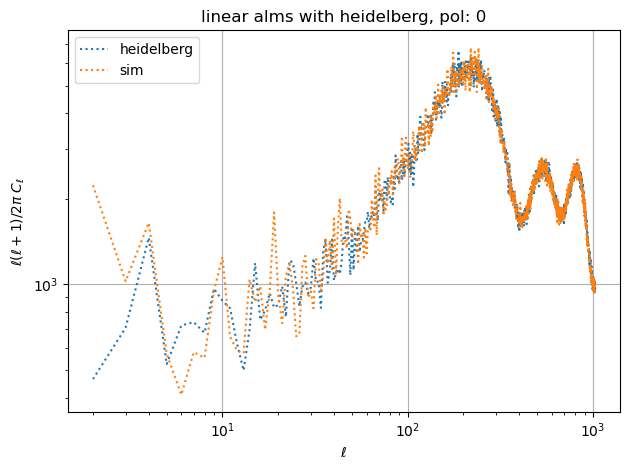

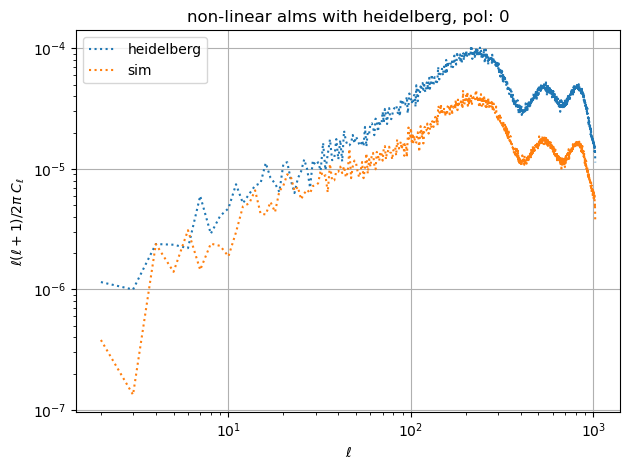

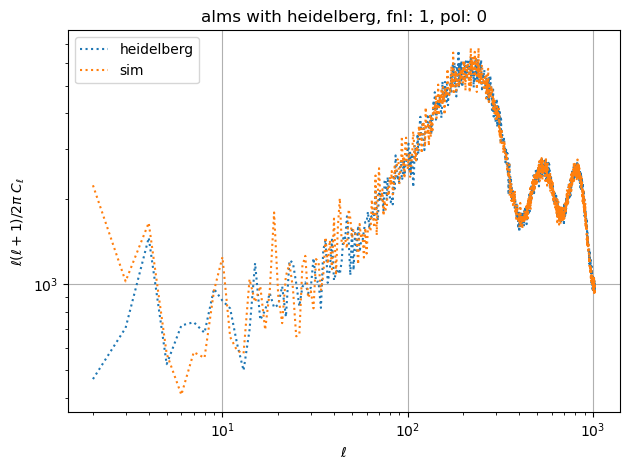

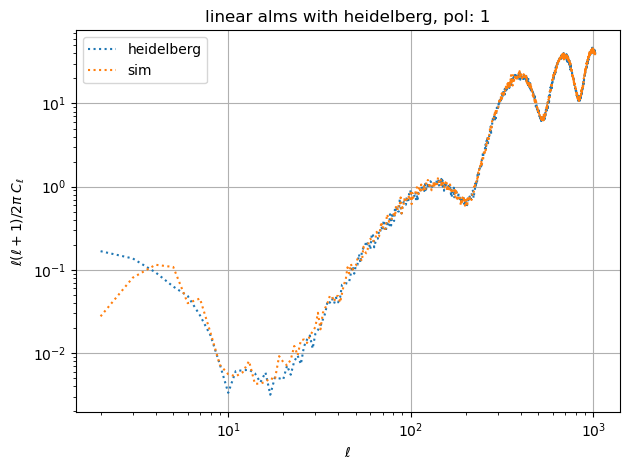

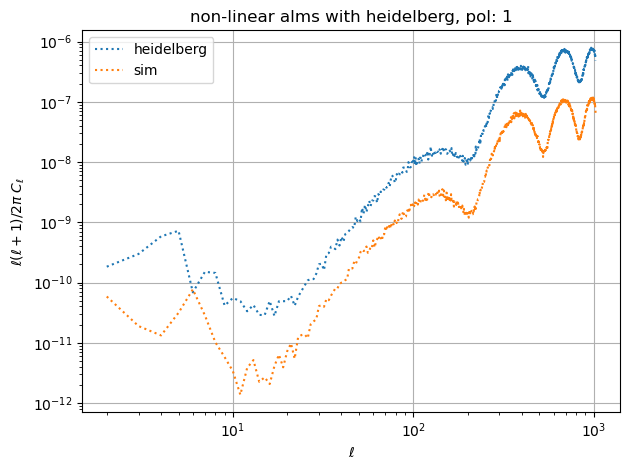

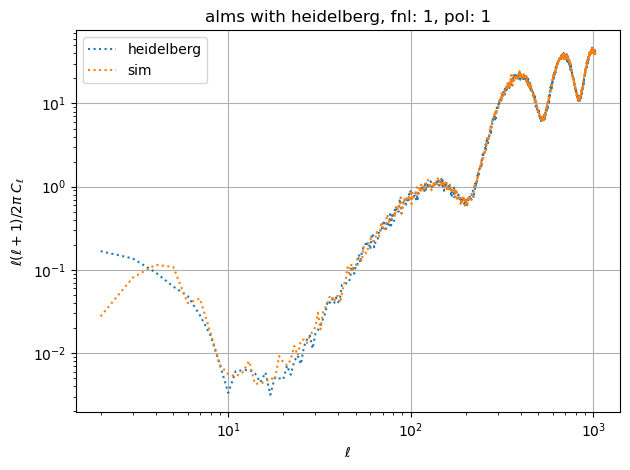

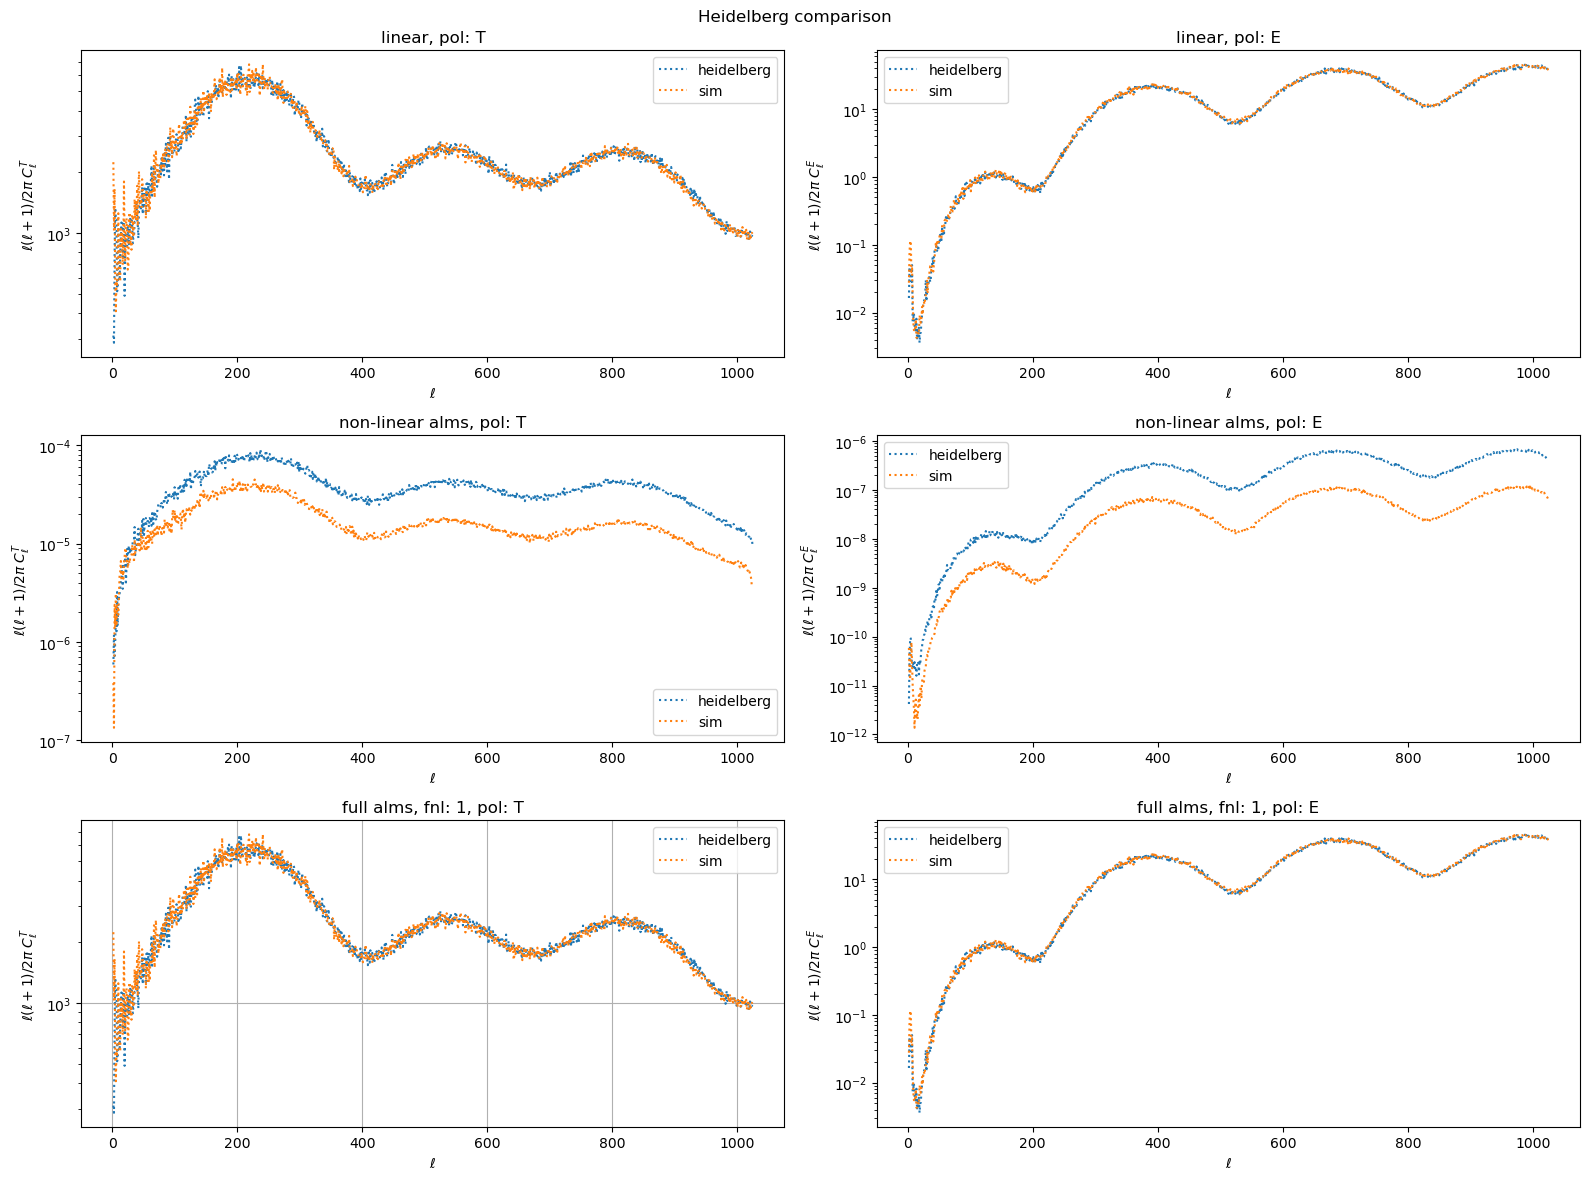

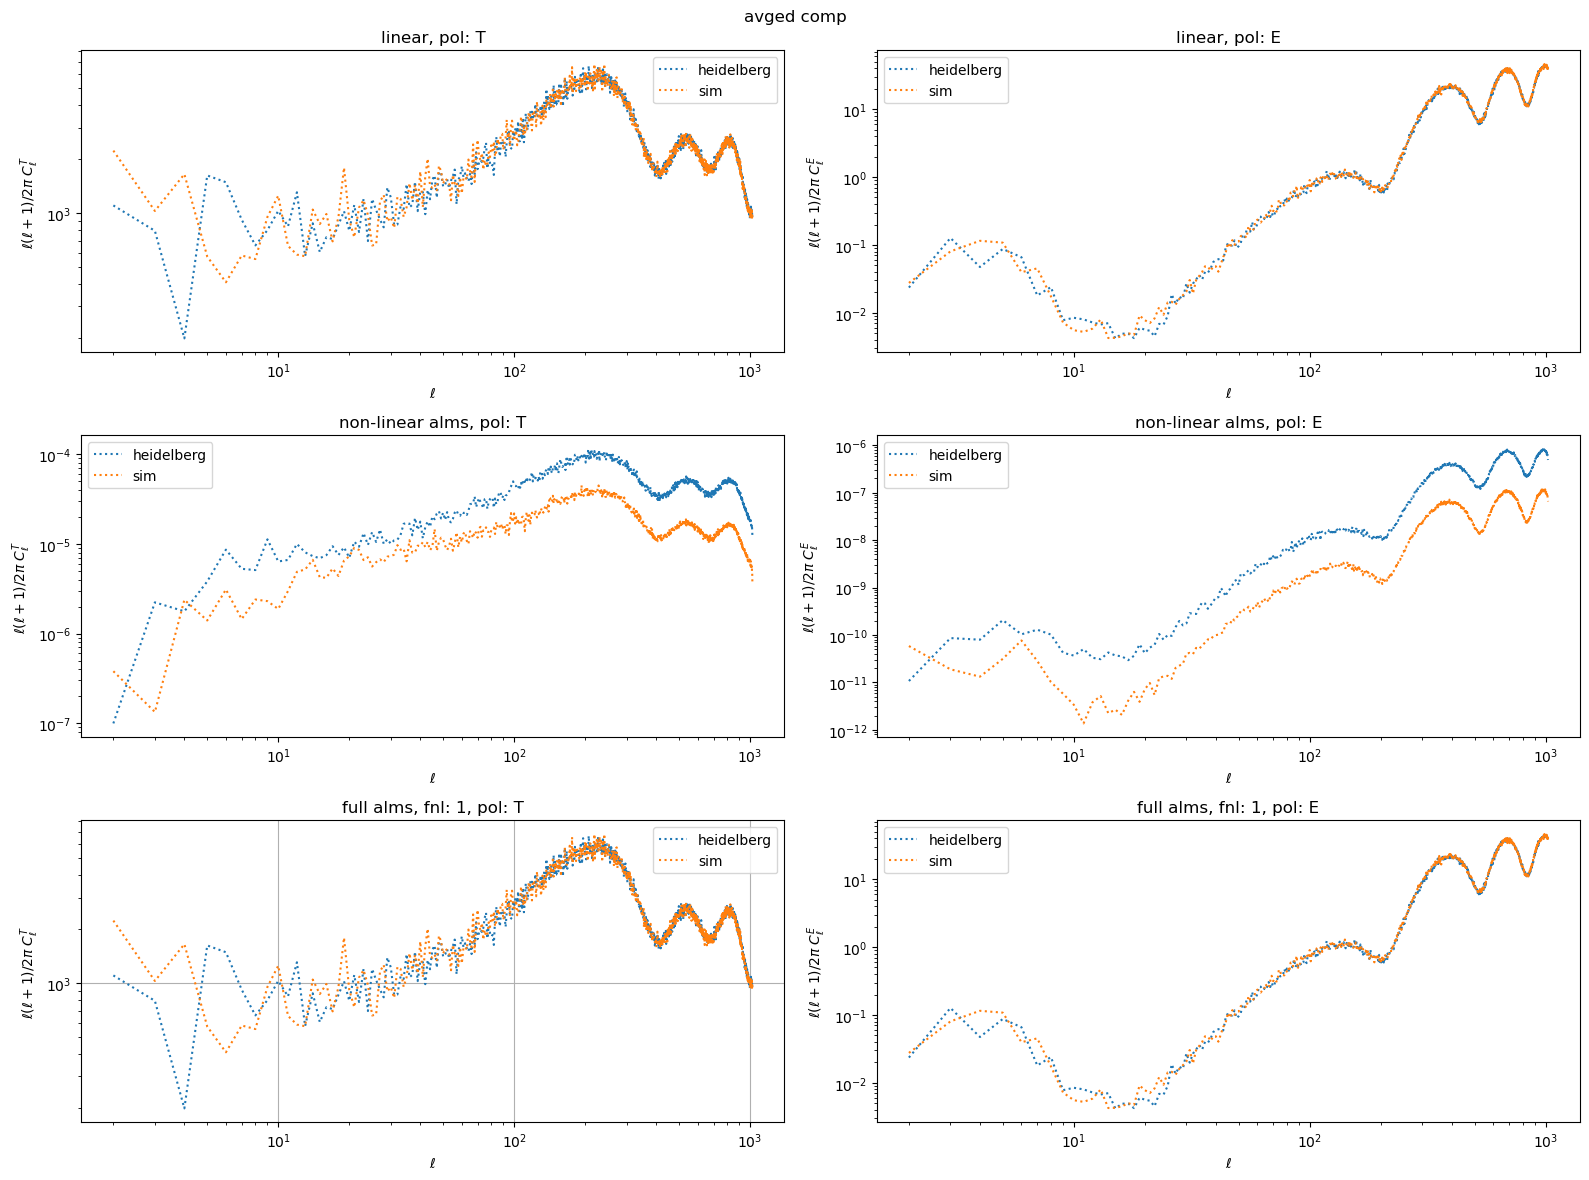

In [15]:
for pol in range(core.npol):
    lin = [alm_heidelberg_l[pol], alm_l[0, pol]]
    plot_cl_alm(
        lin,
        labels=["heidelberg", "sim"],
        title=f"linear alms with heidelberg, pol: {pol}",
        plot_func=plt.loglog,
        show=True,
        close=True,
    )
    nonlin = [alm_heidelberg_nl[pol], alm_ng[0, pol]]
    plot_cl_alm(
        nonlin,
        labels=["heidelberg", "sim"],
        title=f"non-linear alms with heidelberg, pol: {pol}",
        plot_func=plt.loglog,
        show=True,
        close=True,
    )

    comb = [
        alm_heidelberg_l[pol] + alm_heidelberg_nl[pol],
        alm_l[0, pol] + alm_ng[0, pol],
    ]
    plot_cl_alm(
        comb,
        labels=["heidelberg", "sim"],
        title=f"alms with heidelberg, fnl: 1, pol: {pol}",
        plot_func=plt.loglog,
        show=True,
        close=True,
    )

plot_heidel_comp(alm_l[0], alm_ng[0], hei_idx=core.rng.integers(1, 1001), show=True)

alm_l_avg = np.mean(alm_l, axis=0)
alm_ng_avg = np.mean(alm_ng, axis=0)
plot_heidel_comp(
    alm_l_avg,
    alm_ng_avg,
    hei_idx=core.rng.integers(1, 1001),
    title="avged comp",
    show=True,
    plot_func=plt.loglog,
)

## Setup

In [ ]:
core = Core(
    [
        "settings/n64.json",
        # "settings/n128.json",
        # "settings/n2048.json",
        "--nsims",
        "100",
        "--narray",
        "1",
        "--fnl_range",
        "-100",
        "100",
        # "--no-noise",
        # "--lensing",
        "--pols",
    ]
)

## Alm

This code generates the alms

$$a_{\ell m} = a_{\ell m}^{{G}} + f_{NL}^X a_{\ell m}^{NG}$$
with
$$a_{\ell m}^{NG,loc'} = \int dr r^2 \left[ \alpha_\ell(r)\left(\int d^2 \hat{n} Y_{\ell m}^\star (\hat{n}) B(r,\hat{n})^2 \right)\right]$$
and
$$\alpha_\ell(r)=\frac{2}{\pi} \int_0^\infty dk k^2 \Delta_\ell^T(k) j_\ell(k r)$$
$$\beta_\ell(r)=\frac{2}{\pi} \int_0^\infty dk k^{-1} \Delta_\phi \Delta_\ell^T(k) j_\ell(k r)$$
$$B(r, \hat{n}) = \sum_{\ell,m} \frac{\beta_\ell (r)}{C_\ell} a_{\ell m} Y_{\ell m}$$
where $\Delta_\phi$ is primordial normalization, $\Delta_\ell^T(k)$ is the transfer function, $j_\ell(k r)$ are the spherical bessel functions   

In [ ]:
from scripts.generator import generate_alm, generate_alm_ng

In [ ]:
alm_l = generate_alm(core)
alm_ng = generate_alm_ng(core, alm_l)

fnls = core.rng.uniform(core.fnl_min, core.fnl_max, core.fnl_shape)

alms = alm_l + fnls[:, np.newaxis, :] * alm_ng
alms = remove_mono_dipole(alms)

In [ ]:
plot_cl_alm(
    alm_l[0],
    title="linear alms",
    labels=["TT", "EE"] if core.use_pols else "TT",
    plot_camb=True,
    camb_cls=core.c_ells,
    plot_noise=False,
    camb_noise=core.noise_ell,
    plot_full_camb=True,
    camb_beam=core.beam_ell,
)

plot_cl_alm(
    alm_ng[0],
    labels=["TT", "EE"] if core.use_pols else "TT",
    title="non-linear alms",
)

In [ ]:
for pol in range(core.npol):
    plot_cl_alm(
        alms[0, pol],
        title=f"alms final, pol: {pol}",
        plot_camb=True,
        camb_cls=core.c_ells[pol],
        plot_noise=False,
        camb_noise=core.noise_ell[pol],
        plot_full_camb=True,
        camb_beam=core.beam_ell[pol],
    )

## Lensing and Patching

In [ ]:
ps_rad = np.deg2rad(core.patch_side_deg)
res = ps_rad / core.nside

fs_shape, fs_wcs = enmap.fullsky_geometry(res, proj="car")
# need to add a B mode dim if we are using E modes, this is used for some lensing
full_pol = 3 if core.use_pols else core.npol
fs_shape = (full_pol,) + fs_shape
fs_map = enmap.zeros(fs_shape, fs_wcs)

patch_shapes = []
patch_wcss = []
for counter in range(core.npatches // 2):
    # [[dec_min,ra_min],[dec_max,ra_max]]
    top = [[0, ps_rad * counter], [ps_rad, ps_rad * (counter + 1)]]
    gs, w = enmap.geometry(pos=top, res=res, proj="car")
    patch_shapes.append(gs)
    patch_wcss.append(w)

    bottom = [[-ps_rad, ps_rad * counter], [0, ps_rad * (counter + 1)]]
    gs, w = enmap.geometry(pos=bottom, res=res, proj="car")
    patch_shapes.append(gs)
    patch_wcss.append(w)

In [ ]:
# convert the map into a pixell map to allow for projection
if core.lensing:
    cl_phi = core.cosmo._camb_data.get_lens_potential_cls(  # type: ignore
        core.lmax, CMB_unit="muK", raw_cl=True
    )
    plm = lenspyx.utils_hp.synalm(cl_phi[:, 0], lmax=core.lmax, mmax=None)

    # transform the lensing potential into spin-1 deflection field
    fl = np.sqrt(np.arange(core.nell) * np.arange(1, core.nell + 1))
    dlm = lenspyx.utils_hp.almxfl(plm, fl, mmax=None, inplace=False)

    geom_info = ("healpix", {"nside": core.nside})
    geom = lenspyx.get_geom(geom_info)

    patches = np.empty(
        (core.nsims, core.npatches, full_pol, core.nside, core.nside),
        dtype=core.r_dtype,
    )
    alm_lensed = np.empty((core.nsims, full_pol, core.nelem), dtype=core.c_dtype)

    for sim in tqdm(range(core.nsims), desc="Lensing and Patching", total=core.nsims):
        lens_map = lenspyx.alm2lenmap(
            alms[sim], dlm, geometry=geom_info, nthreads=core.n_cpus
        )

        alm_lensed[sim, 0] = geom.map2alm(
            lens_map[0], core.lmax, core.lmax, nthreads=core.n_cpus
        )
        if core.use_pols:
            alm_lensed[sim, 1:] = geom.map2alm_spin(
                lens_map[1:], 2, core.lmax, core.lmax, nthreads=core.n_cpus
            )

        pixell_map = reproject.healpix2map(lens_map, fs_shape, fs_wcs, core.lmax)

        # cut the patches
        for i in range(core.npatches):
            patches[sim, i] = pixell_map.project(patch_shapes[i], patch_wcss[i])

    # lets make a plot
    sim = core.rng.integers(core.nsims)
    # Create a figure with subplots
    fig, axes = plt.subplots(
        1, core.npol, figsize=(15, 5), subplot_kw={"projection": "mollweide"}
    )
    axes = np.atleast_1d(axes)
    for pol in range(core.npol):
        # Create the mollview plot in the corresponding subplot
        plt.axes(axes[pol])
        hp.mollview(
            lens_map[pol], title=f"Simulation {sim}, Polarization {pol}", hold=True
        )
    # Save the combined plot to a file
    # plt.savefig(f"mollview_sim{sim}_combined.png")

    # Optionally, close the plot to free memory
    # plt.close()

else:
    patches = np.empty(
        (core.nsims, core.npatches, core.npol, core.nside, core.nside),
        dtype=core.r_dtype,
    )

    if core.use_pols:
        # need to add a zero for the spin-2 component
        alms = np.concatenate((alms, np.zeros((core.nsims, 1, core.nelem))), axis=1)

    for sim in tqdm(range(core.nsims), desc="Patching", total=core.nsims):
        car_map = curvedsky.alm2map(alms[sim], fs_map, nthread=core.n_cpus, copy=True)

        for i in range(core.npatches):
            patches[sim, i] = car_map.project(patch_shapes[i], patch_wcss[i])[
                : core.npol
            ]  # type: ignore

In [ ]:
for pol in range(core.npol):
    plot_patches(patches[0, :, pol], title=f"Pol {pol}")

In [ ]:
sim = core.rng.integers(core.nsims)
plt_file = os.path.join(
    core.plot_dir, f"{core.sjob}_{core.base_name}_mollview[{sim}].png"
)
if core.lensing:
    map = lenspyx.alm2lenmap(alms[sim], dlm, geom_info, nthreads=core.n_cpus)
    plot_mollview(map, f"Lensed view for {sim}", show=True)  # , save_file=plt_file)
else:
    map = curvedsky.alm2map_healpix(
        alms[sim, 0], nside=core.nside, copy=True, nthread=core.n_cpus
    )
    plot_mollview(map, f"unlensed view for {sim}", show=True)  # , save_file=plt_file)

for pol in range(core.npol):
    pstr = pol_str(pol)
    patch_file = os.path.join(
        core.plot_dir, f"{core.sjob}_{core.base_name}_patch[{sim},{pstr}].png"
    )
    plot_patches(
        patches[sim, :, pol], title=f"Patches for sim: {sim}, pol: {pstr}", show=True
    )  # , save_file=patch_file)

    ylabel = r"$\ell(\ell+1)/2\pi\;C_{\ell}" + f"^{pstr}$"
    filebase = os.path.join(
        core.plot_dir, f"{core.sjob}_{core.base_name}_alm[{sim},{pstr}].png"
    )
    plot_cl_alm(
        alms[sim, pol],
        # save_file=filebase,
        plot_camb=True,
        ylabel=ylabel,
        camb_cls=core.c_ells[pol],
        plot_noise=False,
        plot_full_camb=True,
        camb_noise=core.noise_ell[pol],
        camb_beam=core.beam_ell[pol],
        show=True,
    )

hei_file = os.path.join(core.plot_dir, f"{core.sjob}_{core.base_name}_hei.png")
plot_heidel_comp(
    alm_l[sim], alm_ng[sim], hei_idx=core.rng.integers(1, 1001), show=True
)  # save_file=hei_file)

## Estimator

In [ ]:
from ksw import Cosmology, Shape, Data
import camb
from scripts.estimator import icov_func, conv_beam_func, run_ksw_step

In [ ]:
cosmo_params = core.cosmo_params
cosmo = Cosmology(camb.set_params(**cosmo_params))
cosmo.compute_transfer(core.max_l)
cosmo.compute_c_ell()

noise = core.noise_ell[: core.npol]
beam = core.beam_ell[: core.npol]
c_ells = core.c_ells[: core.npol]

loc_shape = Shape.prim_local(cosmo_params["ns"], cosmo_params["pivot_scalar"])
cosmo.add_prim_reduced_bispectrum(loc_shape, core.radii)

icov = icov_func(beam, noise, c_ells)

ksw = KSW_joblib(
    cosmo.red_bispectra,
    icov,
    conv_beam_func(core),
    core.lmax,
    core.pols,
    core.precision,
)

# uncomment to remove the mc file to regenerated
if os.path.exists(core.mc_file):
    os.remove(core.mc_file)

In [ ]:
theta_batch = int(np.floor(1.5 * core.lmax + 1)) // core.n_cpus

if False and os.path.exists(core.mc_file):
    print("Loading KSW state from ", core.mc_file)
    ksw.start_from_read_state(core.mc_file, None)
else:
    run_ksw_step(ksw, core, theta_batch)
    # print("Saving KSW state to", core.mc_file)
    # ksw.write_state(core.mc_file)

In [ ]:
fisher = ksw.compute_fisher()
print(f"Fisher: {fisher}, standard deviation: {np.sqrt(1 / fisher)}")

In [ ]:
pbar = tqdm(total=core.nsims, desc="Computing estimates")


def alm_loader(i):
    pbar.update(1)
    if core.lensing:
        return alm_lensed[i, : core.npol]
    else:
        return alms[i, : core.npol]


idxs = range(alms.shape[0])

estimates = ksw.compute_estimate_batch(
    alm_loader, idxs, theta_batch=theta_batch, fisher=fisher
)
pbar.close()

In [ ]:
fnls = np.array(fnls[idxs]).flatten()
diff = estimates - fnls
std_dev = np.sqrt(1 / fisher)
sem = std_dev / np.sqrt(len(diff))
logger.info("Standard deviation: %s, SEM: %s", std_dev, sem)
for i in range(3):
    within = np.sum(np.abs(diff) < ((i + 1) * std_dev))
    percentage = within / len(diff) * 100
    within_error = np.sum(np.abs(diff) < ((i + 1) * (std_dev + sem)))
    percentage_error = within_error / len(diff) * 100
    print(
        f"{percentage}% are within {i+1} standard deviations, and {percentage_error}% are within standard deviations with error."
    )

plot_predictions(fnls, estimates, fisher=fisher)
plot_histogram(fnls, estimates)